In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# ==========================
# Load Data
# ==========================

rgb = pd.read_csv("rgb2-features.csv")
weights = pd.read_csv("plant-weights.csv")

# ==========================
# Aggregate Measurements
# ==========================

weight_df = (
    weights.groupby(["plant_id", "round_id"])["weight_g"]
    .mean()
    .reset_index()
)

numeric_rgb = rgb.select_dtypes(include=np.number).columns.tolist()
numeric_rgb = [c for c in numeric_rgb if c not in ["plant_id", "round_id"]]

rgb_df = (
    rgb.groupby(["plant_id", "round_id"])[numeric_rgb]
    .mean()
    .reset_index()
)

merged = rgb_df.merge(
    weight_df,
    on=["plant_id", "round_id"],
    how="inner"
)

print("Merged observations:", len(merged))

# ==========================
# Top Correlations
# ==========================

corrs = (
    merged.select_dtypes(include=np.number)
    .corr()["weight_g"]
    .sort_values(ascending=False)
)

print("\nTop correlations with weight:")
print(corrs.head(20))

# ==========================
# Plot 1:
# Top Feature Correlations
# ==========================

top_features = corrs.drop("weight_g").abs().nlargest(15)



Merged observations: 23580

Top correlations with weight:
weight_g                          1.000000
red_median                        0.315378
lightness_median                  0.306060
red_mean                          0.303363
brightness_median                 0.300864
lightness_mean                    0.289187
green_median                      0.289087
brightness_mean                   0.285379
green_mean                        0.273382
hue_bin_04_057p6_072p0deg_prop    0.232812
blue_mean                         0.215844
blue-yellow_median                0.201203
blue_median                       0.196892
hue_bin_03_043p2_057p6deg_prop    0.193242
proportional_red_mean             0.171593
feature_bbox_row_start_px         0.157673
bbox_top_px                       0.157673
hue_bin_10_144p0_158p4deg_prop    0.157386
hue_bin_13_187p2_201p6deg_prop    0.152509
hue_bin_12_172p8_187p2deg_prop    0.149584
Name: weight_g, dtype: float64


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

rgb = pd.read_csv("rgb2-features.csv")
wt = pd.read_csv("plant-weights.csv")

# ----------------------
# Water gain
# ----------------------

water = wt.dropna(
    subset=["weight_after_watering_g"]
).copy()

water["water_gain"] = (
    water["weight_after_watering_g"]
    - water["weight_g"]
)

water["water_gain_pct"] = (
    water["water_gain"]
    / water["weight_g"]
) * 100

print(water["water_gain"].describe())
print(water["water_gain_pct"].describe())

count    20730.000000
mean         5.663353
std         11.251883
min       -809.000000
25%          0.000000
50%          3.200000
75%          6.300000
max        172.000000
Name: water_gain, dtype: float64
count    2.072500e+04
mean              inf
std               NaN
min     -1.000000e+02
25%      0.000000e+00
50%      1.827527e+00
75%      3.712297e+00
max               inf
Name: water_gain_pct, dtype: float64


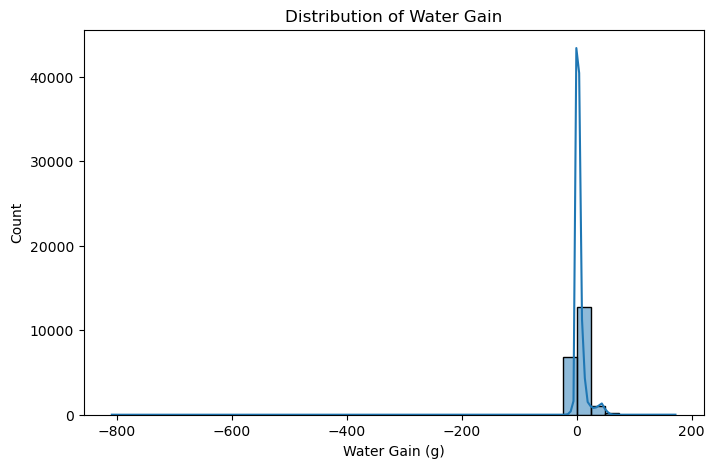

In [4]:
plt.figure(figsize=(8,5))

sns.histplot(
    water["water_gain"],
    bins=40,
    kde=True
)

plt.title("Distribution of Water Gain")
plt.xlabel("Water Gain (g)")
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\regression.py:246: RuntimeWarning: invalid value encountered in dot
  yhat = grid.dot(reg_func(X, y))
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\regression.py:255: RuntimeWarning: invalid value encountered in dot
  yhat_boots = grid.dot(beta_boots).T


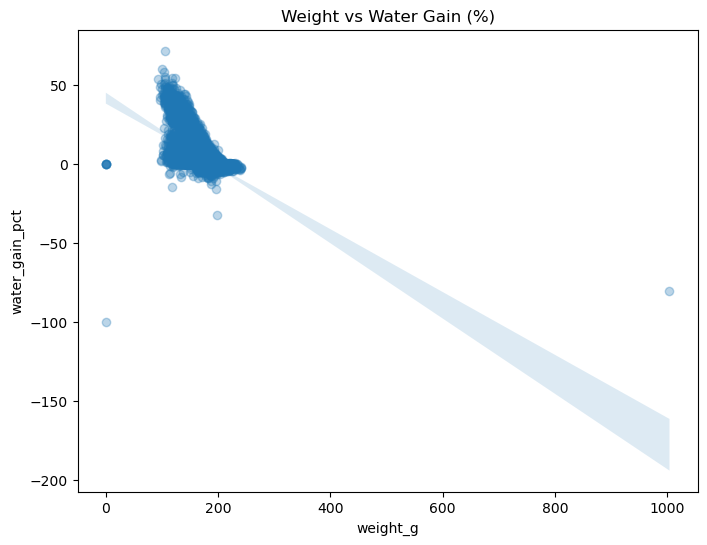

In [5]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=water,
    x="weight_g",
    y="water_gain_pct",
    scatter_kws={"alpha":0.3}
)

plt.title(
    "Weight vs Water Gain (%)"
)

plt.show()

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
rgb = pd.read_csv("rgb2-features.csv")
wt = pd.read_csv("plant-weights.csv")

In [15]:
wt = wt.copy()
wt["water_gain"] = (
wt["weight_after_watering_g"]
- wt["weight_g"]
)
wt["water_gain_pct"] = (
wt["water_gain"]
/ wt["weight_g"]
) * 100
wt = wt[wt["weight_g"] < 500]

In [17]:
numeric_rgb = rgb.select_dtypes(include=np.number).columns.tolist()
remove_cols = [
"plant_id",
"round_id",
"experiment_id"
]
numeric_rgb = [
c for c in numeric_rgb
if c not in remove_cols
]
rgb_agg = (
rgb.groupby(["plant_id","round_id"])[numeric_rgb]
.mean()
.reset_index()
)
wt_agg = (
wt.groupby(["plant_id","round_id"])
.agg({
"weight_g":"mean",
"water_gain":"mean",
"water_gain_pct":"mean"
})
.reset_index()
)
merged = rgb_agg.merge(
wt_agg,
on=["plant_id","round_id"],
how="inner"
)
print("Merged observations:", len(merged))

Merged observations: 23579



Top Water Gain Correlations
water_gain                        1.000000
water_gain_pct                    0.982142
area_px                           0.698301
area_mm2                          0.698301
convex_area_px                    0.685587
convex_area_mm2                   0.685587
mask_coverage_pct                 0.685427
bbox_height_mm                    0.645749
bbox_height_px                    0.645749
bbox_width_px                     0.639922
bbox_width_mm                     0.639922
convex_perimeter_px               0.633285
convex_perimeter_mm               0.633270
perimeter_mm                      0.612630
perimeter_px                      0.612629
weight_g                         -0.566059
round_id                          0.527159
hue_bin_06_086p4_100p8deg_prop    0.408371
red_median                       -0.319569
red_mean                         -0.304280
Name: water_gain, dtype: float64


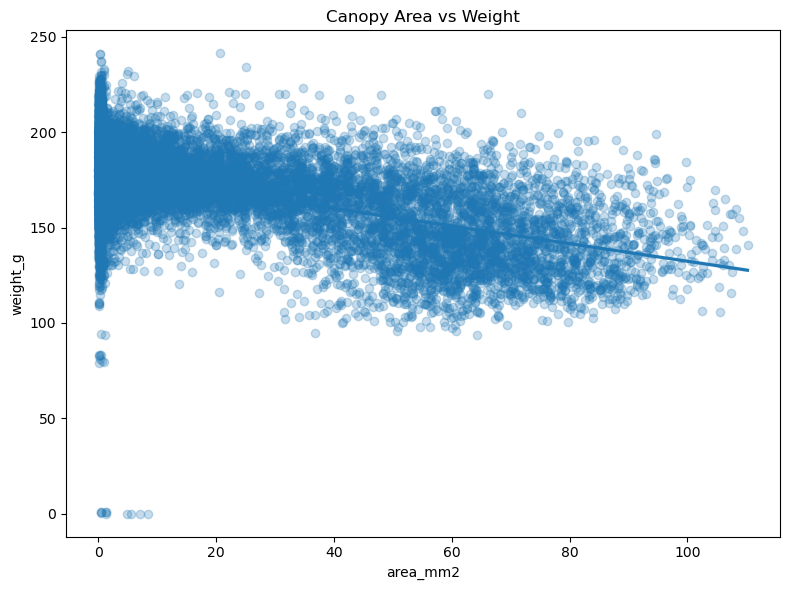

In [22]:
water_subset = merged.dropna(
subset=["water_gain"]
)
corr_water = (
water_subset.select_dtypes(np.number)
.corr()["water_gain"]
.sort_values(
key=np.abs,
ascending=False
)
)
print("\nTop Water Gain Correlations")
print(corr_water.head(20))
# =====================================================
# 3. AREA VS WEIGHT
# =====================================================
plt.figure(figsize=(8,6))
sns.regplot(
data=merged,
x="area_mm2",
y="weight_g",
scatter_kws={"alpha":0.25}
)
plt.title(
"Canopy Area vs Weight"
)
plt.tight_layout()
plt.show()

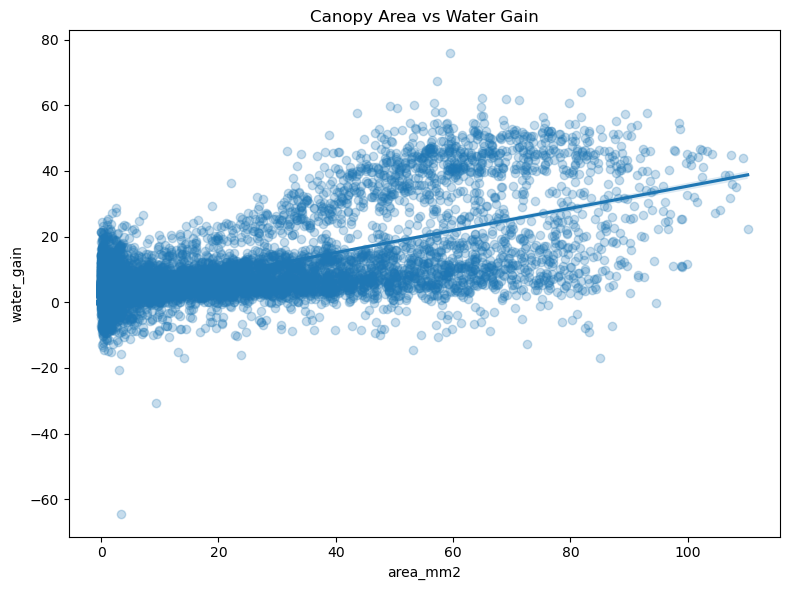

In [24]:
plt.figure(figsize=(8,6))
sns.regplot(
data=water_subset,
x="area_mm2",
y="water_gain",
scatter_kws={"alpha":0.25}
)
plt.title(
"Canopy Area vs Water Gain"
)
plt.tight_layout()
plt.show()

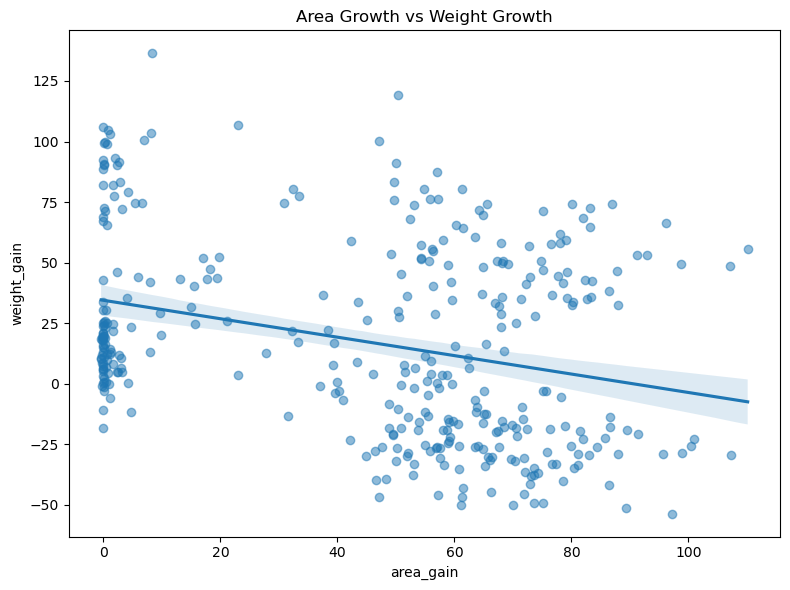


Area Gain vs Weight Gain Correlation:
-0.29990484852965893


In [25]:
growth = (
merged.sort_values("round_id")
.groupby("plant_id")
.agg({
"weight_g":["first","last"],
"area_mm2":["first","last"]
})
)
growth.columns = [
"weight_start",
"weight_end",
"area_start",
"area_end"
]
growth["weight_gain"] = (
growth["weight_end"]
- growth["weight_start"]
)
growth["area_gain"] = (
growth["area_end"]
- growth["area_start"]
)
growth = growth.dropna()
plt.figure(figsize=(8,6))
sns.regplot(
data=growth,
x="area_gain",
y="weight_gain",
scatter_kws={"alpha":0.5}
)
plt.title(
"Area Growth vs Weight Growth"
)
plt.tight_layout()
plt.show()
print(
"\nArea Gain vs Weight Gain Correlation:"
)
print(
growth["area_gain"].corr(
growth["weight_gain"]
)
)

In [26]:
survival = (
wt.groupby("plant_id")
.agg({
"round_id":"nunique",
"weight_g":"max"
})
)
survival.columns = [
"rounds_observed",
"max_weight"
]
survival["survival_score"] = (
survival["rounds_observed"]
*
survival["max_weight"]
)
print("\nTop Survivors")
print(
survival.sort_values(
"survival_score",
ascending=False
).head(20)
)


Top Survivors
          rounds_observed  max_weight  survival_score
plant_id                                             
29097                  72       241.3         17373.6
29034                  72       241.2         17366.4
28925                  72       237.4         17092.8
28946                  71       238.5         16933.5
29036                  72       232.9         16768.8
28936                  72       231.9         16696.8
29042                  72       229.4         16516.8
29060                  72       229.2         16502.4
29050                  72       228.5         16452.0
29061                  72       228.3         16437.6
28938                  72       227.8         16401.6
29041                  72       227.7         16394.4
28940                  72       227.5         16380.0
29084                  72       227.3         16365.6
29052                  72       226.3         16293.6
29045                  72       226.1         16279.2
29048        